In [1]:
import sys
import os
import polars as pl
import numpy as np
# Add the project root directory to PYTHONPATH
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
sys.path.insert(0, project_root)

# Import necessary modules
import groundinsight as gi
from groundinsight.models.core_models import BusType, BranchType




In [7]:
#Test the calculation formula of the impedance

rho = 100

# Create a network
net = gi.create_network(name="MyTestNetwork", frequencies=[50, 250, 350])
net.description = "CIRED example Network"

bus_type = BusType(
    name="BusTypeFormulaTest",
    description="Example bus type with parameters",
    system_type="Grounded",
    voltage_level=20,
    impedance_formula="0.01201149 * rho + 0.00024195 * f - 0.00000034 * rho*f + 0.01444725 + 1j * (-0.00003812 * rho + 0.00030091 * f + 0.00000089*rho*f + 0.01997045)",
)

bus_type_uw = BusType(
    name="BusTypeFormulaTestUW",
    description="Example bus type with parameters",
    system_type="Grounded",
    voltage_level=20,
    impedance_formula="0.2"
    )

self_impedance_formula = "(0.24/1000 + (2*pi*f * 4*pi*10**(-7) / 8) + 1j * (2*pi*f * 4*pi*10**(-7) / (2 * pi)) * log((1.8514 / sqrt(2 * pi * f * 4*pi*10**(-7) / rho)) / (0.040**2 * 0.035)**(1/3)))*l"
mutual_impedance_formula = "((2*pi*f * 4*pi*10**(-7) / 8) + 1j * (2*pi*f * 4*pi*10**(-7) / (2 * pi)) * log((1.8514 / sqrt(2 * pi * f * 4*pi*10**(-7) / rho)) / (0.040**2 * 0.035)**(1/3)))*l"

branch_type = BranchType(
    name="TestBranchType",
    description="A test branch type",
    grounding_conductor=True,
    self_impedance_formula=self_impedance_formula,
    mutual_impedance_formula=mutual_impedance_formula
)

branch_ohl = BranchType(
    name="OHLine",
    description="An overhead line",
    grounding_conductor=False,
    self_impedance_formula="NaN",
    mutual_impedance_formula="NaN"
)

number_buses = 11
#create buses with a for loop
for i in range(1, number_buses):
    gi.create_bus(name=f"bus{i}", type=bus_type, network=net, specific_earth_resistance=rho)


#create branch 
#defining a line length of each branch
line_length = 1000

#create bracnches with a for loop
for i in range(1, number_buses-1):
    gi.create_branch(name=f"branch{i}", type=branch_type, from_bus=f"bus{i}", to_bus=f"bus{i+1}", length=line_length, specific_earth_resistance=rho, network=net)



#create a faults
fault_scaling = {50: 1.0, 250: 1, 350:1}
faultnames = []
for i in range(1, number_buses):
    gi.create_fault(name=f"fault{i}", bus=f"bus{i}", description="A fault at bus {i}", scalings=fault_scaling, network=net)
    faultnames.append(f"fault{i}")


#soruce currents
source_values = {50:60, 250:60, 350:60}

#add a source at bus1
source = gi.create_source(name="source1", bus="bus1", values=source_values, network=net)

#define the paths of the network
gi.create_paths(network=net)

#for loop over each fault
for i in range(number_buses-1):
    # Run fault calculations
    gi.run_fault(net, fault_name=f"fault{i+1}")



# Access the reduction factors
result = net.results["fault7"]
reduction_factors = result.reduction_factor.value

# Access the grounding impedances
grounding_impedances = result.grounding_impedance.value

# Print reduction factors
for freq, rf in reduction_factors.items():
    print(f"Frequency: {freq} Hz, Reduction Factor: {rf}")

# Print the grounding impedances
for freq, z in grounding_impedances.items():
    try:
        print(f"Frequency: {freq} Hz, Grounding Impedance: {np.abs(z)}")
    except:
        print("Exception")






Frequency: 50.0 Hz, Reduction Factor: 0.3440948014589249
Frequency: 250.0 Hz, Reduction Factor: 0.08106354065118268
Frequency: 350.0 Hz, Reduction Factor: 0.05915750617329908
Frequency: 50.0 Hz, Grounding Impedance: 0.4533065133571081
Frequency: 250.0 Hz, Grounding Impedance: 0.8587584300205859
Frequency: 350.0 Hz, Grounding Impedance: 0.9624405455273086


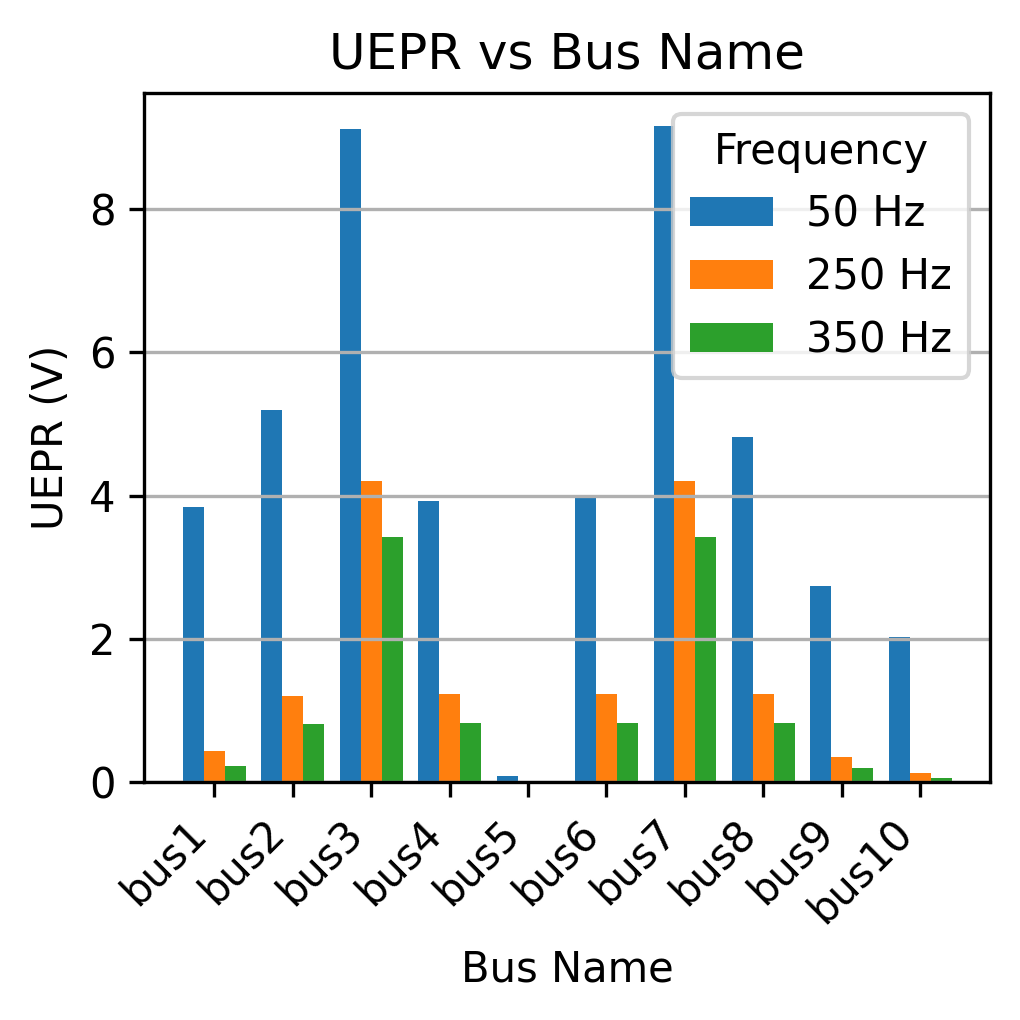

In [6]:
# Plot the results
#set matplotlib fontisze to 10
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10})

#set the dpi of all figures default to 300
plt.rcParams.update({'figure.dpi': 300})

#update to scientific notation
plt.rcParams.update({'axes.formatter.useoffset': False})

gi.plot_bus_voltages(result=result, frequencies=[50, 250, 350], show=False, figsize=(3.5, 3.5));

